<a href="https://colab.research.google.com/github/jesmithamylavarapu-code/neuro_ps1/blob/main/ps1img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Cell 1 — clone only the folder you need (sparse checkout, fast & light)
!git clone --filter=blob:none --no-checkout --depth 1 https://github.com/Horea94/Fruit-Images-Dataset.git
%cd Fruit-Images-Dataset
!git sparse-checkout init --cone
!git sparse-checkout set Training
!git checkout
%cd ..

Cloning into 'Fruit-Images-Dataset'...
remote: Enumerating objects: 276, done.
remote: Counting objects: 100% (276/276), done.
remote: Compressing objects: 100% (275/275), done.
remote: Total 276 (delta 0), reused 205 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (276/276), 2.09 MiB | 24.57 MiB/s, done.
/content/Fruit-Images-Dataset
remote: Enumerating objects: 67691, done.
remote: Counting objects: 100% (67691/67691), done.
remote: Compressing objects: 100% (67691/67691), done.
remote: Total 67691 (delta 0), reused 67689 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (67691/67691), 287.75 MiB | 26.40 MiB/s, done.
Updating files: 100% (67694/67694), done.
Your branch is up to date with 'origin/master'.
/content


In [15]:
# Cell 2 — list available fruit folders, then pick yours
import os

training_path = "Fruit-Images-Dataset/Training"
fruit_folders = sorted(os.listdir(training_path))
print(fruit_folders)   # scan this list and copy the exact folder name you want

['Apple Braeburn', 'Apple Crimson Snow', 'Apple Golden 1', 'Apple Golden 2', 'Apple Golden 3', 'Apple Granny Smith', 'Apple Pink Lady', 'Apple Red 1', 'Apple Red 2', 'Apple Red 3', 'Apple Red Delicious', 'Apple Red Yellow 1', 'Apple Red Yellow 2', 'Apricot', 'Avocado', 'Avocado ripe', 'Banana', 'Banana Lady Finger', 'Banana Red', 'Beetroot', 'Blueberry', 'Cactus fruit', 'Cantaloupe 1', 'Cantaloupe 2', 'Carambula', 'Cauliflower', 'Cherry 1', 'Cherry 2', 'Cherry Rainier', 'Cherry Wax Black', 'Cherry Wax Red', 'Cherry Wax Yellow', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Corn Husk', 'Cucumber Ripe', 'Cucumber Ripe 2', 'Dates', 'Eggplant', 'Fig', 'Ginger Root', 'Granadilla', 'Grape Blue', 'Grape Pink', 'Grape White', 'Grape White 2', 'Grape White 3', 'Grape White 4', 'Grapefruit Pink', 'Grapefruit White', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Lemon Meyer', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mango Red', 'Mangostan', 'Maracuja', 'Melo

In [24]:
# Cell 3 — pull 18 images of your chosen fruit into a clean 'combined' folder
import os, random, shutil

matches = [f for f in fruit_folders if "guava" in f.lower()]
print("Matching folders found:", matches)

fruit_name = matches[0]
src = os.path.join(training_path, fruit_name)

os.makedirs("combined", exist_ok=True)

for f in os.listdir("combined"):
    os.remove(os.path.join("combined", f))

all_files = os.listdir(src)
chosen = random.sample(all_files, min(18, len(all_files)))

for i, f in enumerate(chosen):
    shutil.copy(os.path.join(src, f), f"combined/fruit_{i}.jpg")

print(f"Using folder: {fruit_name}")
print(f"Copied {len(chosen)} images into 'combined/'")

Matching folders found: ['Guava']
Using folder: Guava
Copied 18 images into 'combined/'


Dataset shape: (18, 224, 224, 3)


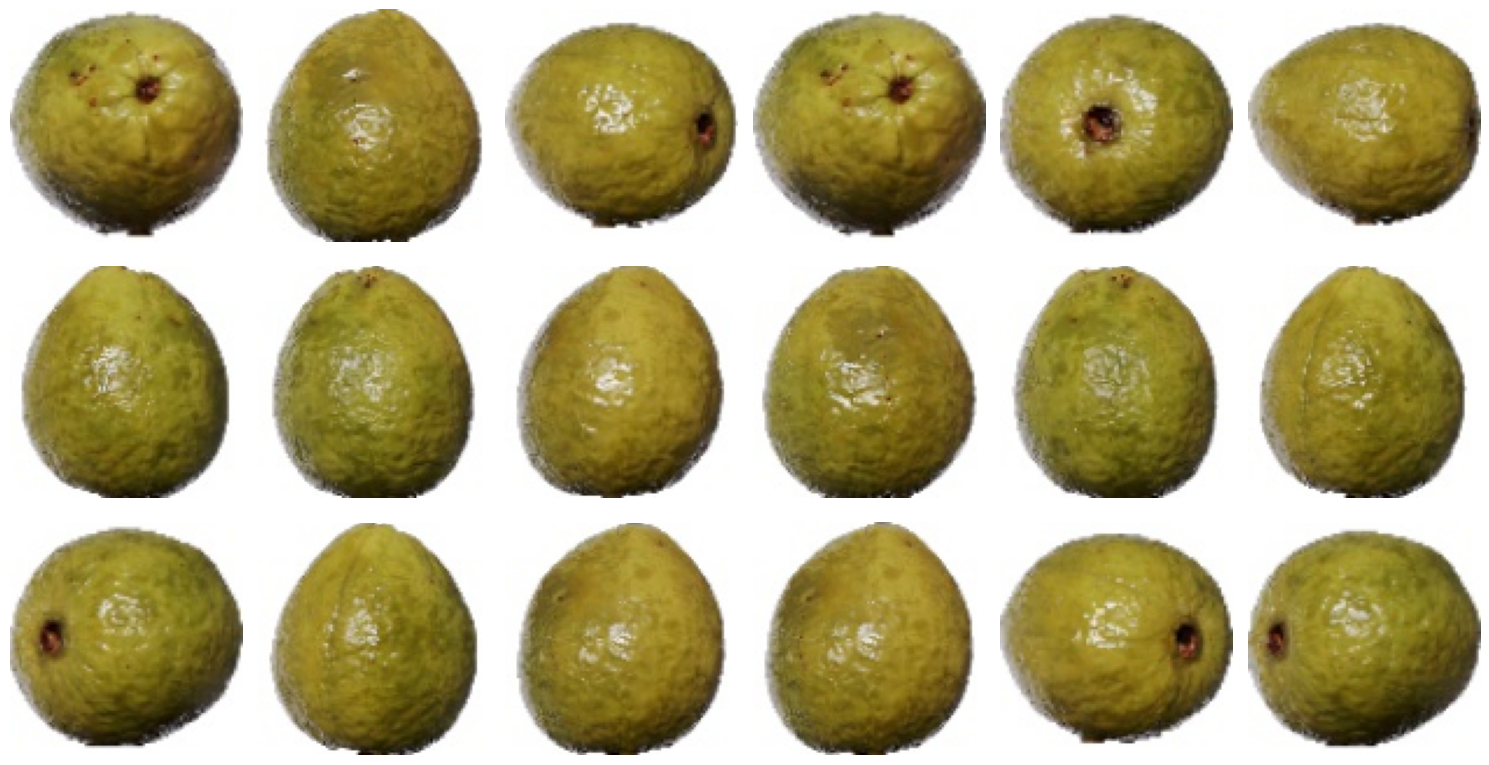

In [25]:
# Cell 4 — preprocessing: resize, normalize, visualize (same as before)
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import glob

TARGET_SIZE = (224, 224)
image_paths = glob.glob("combined/*.jpg")

arrays = []
for p in image_paths:
    img = Image.open(p).convert("RGB").resize(TARGET_SIZE)   # uniform size
    arr = np.asarray(img).astype("float32") / 255.0            # normalize 0-1
    arrays.append(arr)

dataset = np.stack(arrays)
np.save("preprocessed_dataset.npy", dataset)
print("Dataset shape:", dataset.shape)

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for ax, p in zip(axes.flatten(), image_paths):
    ax.imshow(Image.open(p))
    ax.axis("off")
plt.tight_layout()
plt.show()

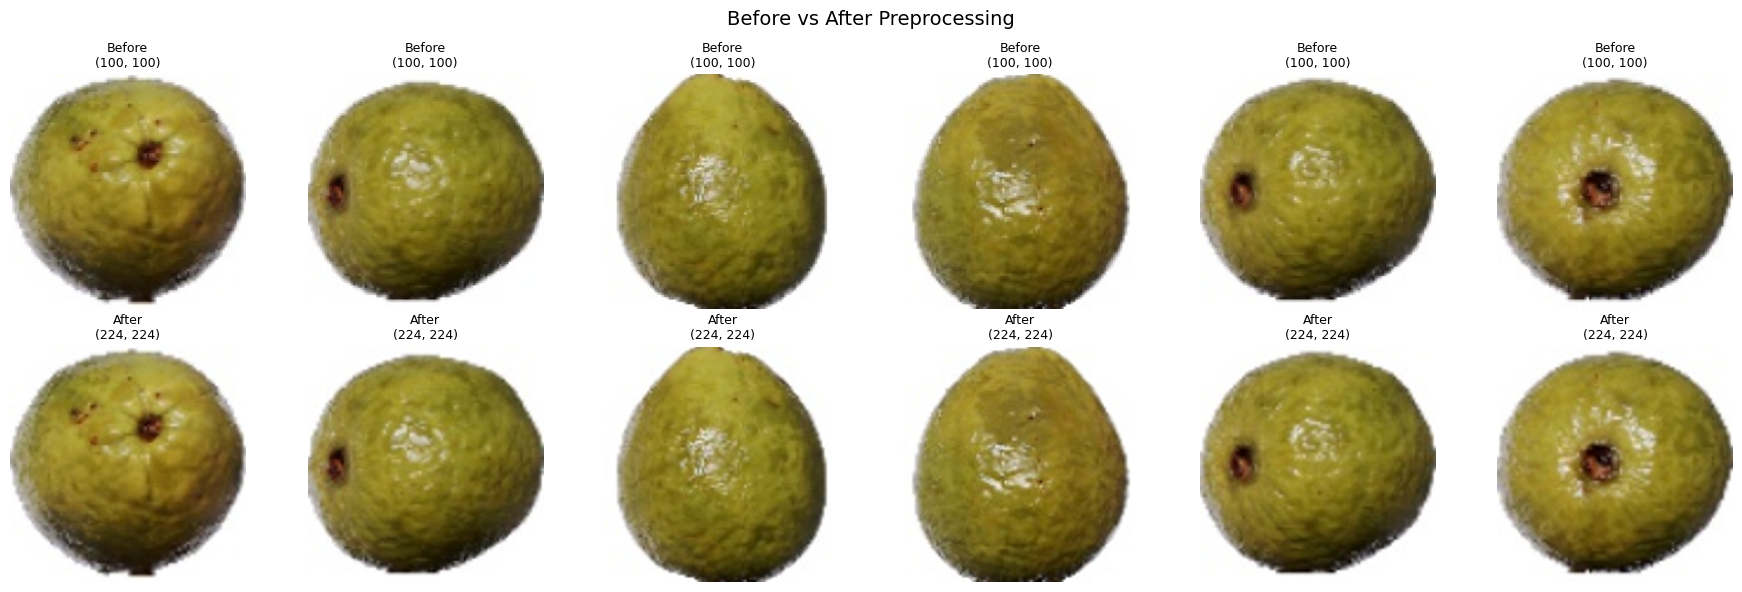

In [26]:
# Cell 5 — show BEFORE (raw) vs AFTER (preprocessed) side by side
from PIL import Image
import matplotlib.pyplot as plt
import glob

TARGET_SIZE = (224, 224)
image_paths = sorted(glob.glob("combined/*.jpg"))[:6]   # show first 6 as example

fig, axes = plt.subplots(2, len(image_paths), figsize=(3 * len(image_paths), 6))

for i, p in enumerate(image_paths):
    original = Image.open(p).convert("RGB")

    # "after" = same preprocessing steps as Cell 4: resize + normalize
    preprocessed = original.resize(TARGET_SIZE)

    axes[0, i].imshow(original)
    axes[0, i].set_title(f"Before\n{original.size}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(preprocessed)
    axes[1, i].set_title(f"After\n{preprocessed.size}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Before vs After Preprocessing", fontsize=14)
plt.tight_layout()
plt.show()